# Bike Sharing Demand Prediction — Exploratory Data Analysis

Regression on the UCI Bike Sharing hourly dataset (17,379 hours, 17 features, Washington DC bike-rental system, 2011–2012). Target: `cnt` (total bike rentals in that hour). Features cover season, hour, weather, temperature, humidity, and wind. The leakage columns `casual` and `registered` are dropped on load.

**Target:** `cnt` (continuous)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/hour.csv')
drop_cols = [c for c in ['instant', 'dteday', 'casual', 'registered'] if c in df.columns]
df = df.drop(columns=drop_cols)
print('Shape:', df.shape)
df.head()

Shape: (17379, 13)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (17379, 13)

Dtypes:
int64      9
float64    4
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,mean,std,min,25%,50%,75%,max
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000


In [5]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 2
Memory (MB): 1.72


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

No missing values


## 4. Target Variable Distribution

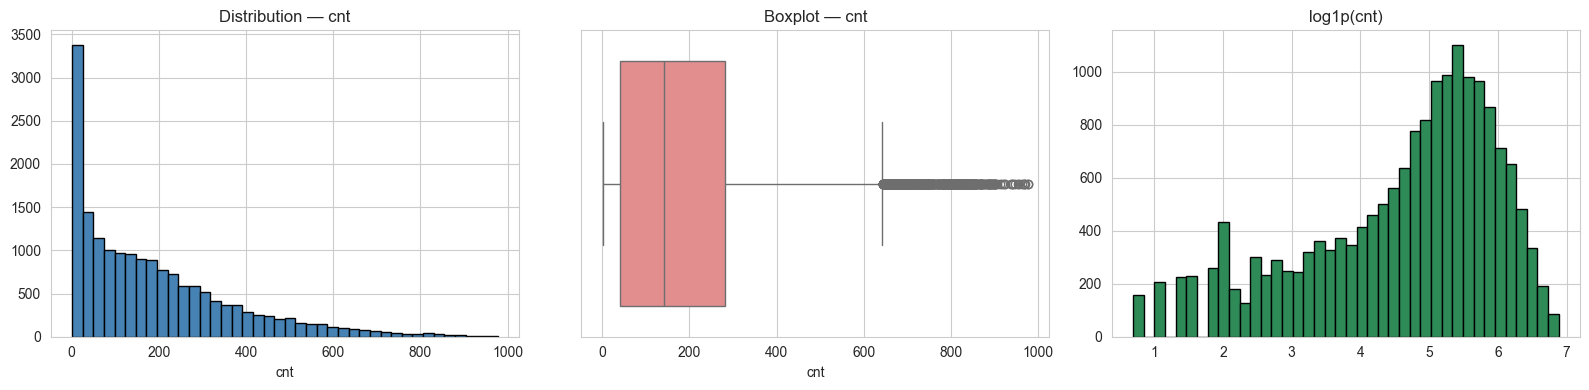

Skewness : 1.277
Kurtosis : 1.417
count    17379.00
mean       189.46
std        181.39
min          1.00
25%         40.00
50%        142.00
75%        281.00
max        977.00
Name: cnt, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['cnt'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — cnt')
axes[0].set_xlabel('cnt')
sns.boxplot(x=df['cnt'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — cnt')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['cnt'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(cnt)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['cnt'].skew(), 3))
print('Kurtosis :', round(df['cnt'].kurtosis(), 3))
print(df['cnt'].describe().round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'cnt' in numeric_cols:
    numeric_cols.remove('cnt')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols[:30])

Numeric features (12):
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


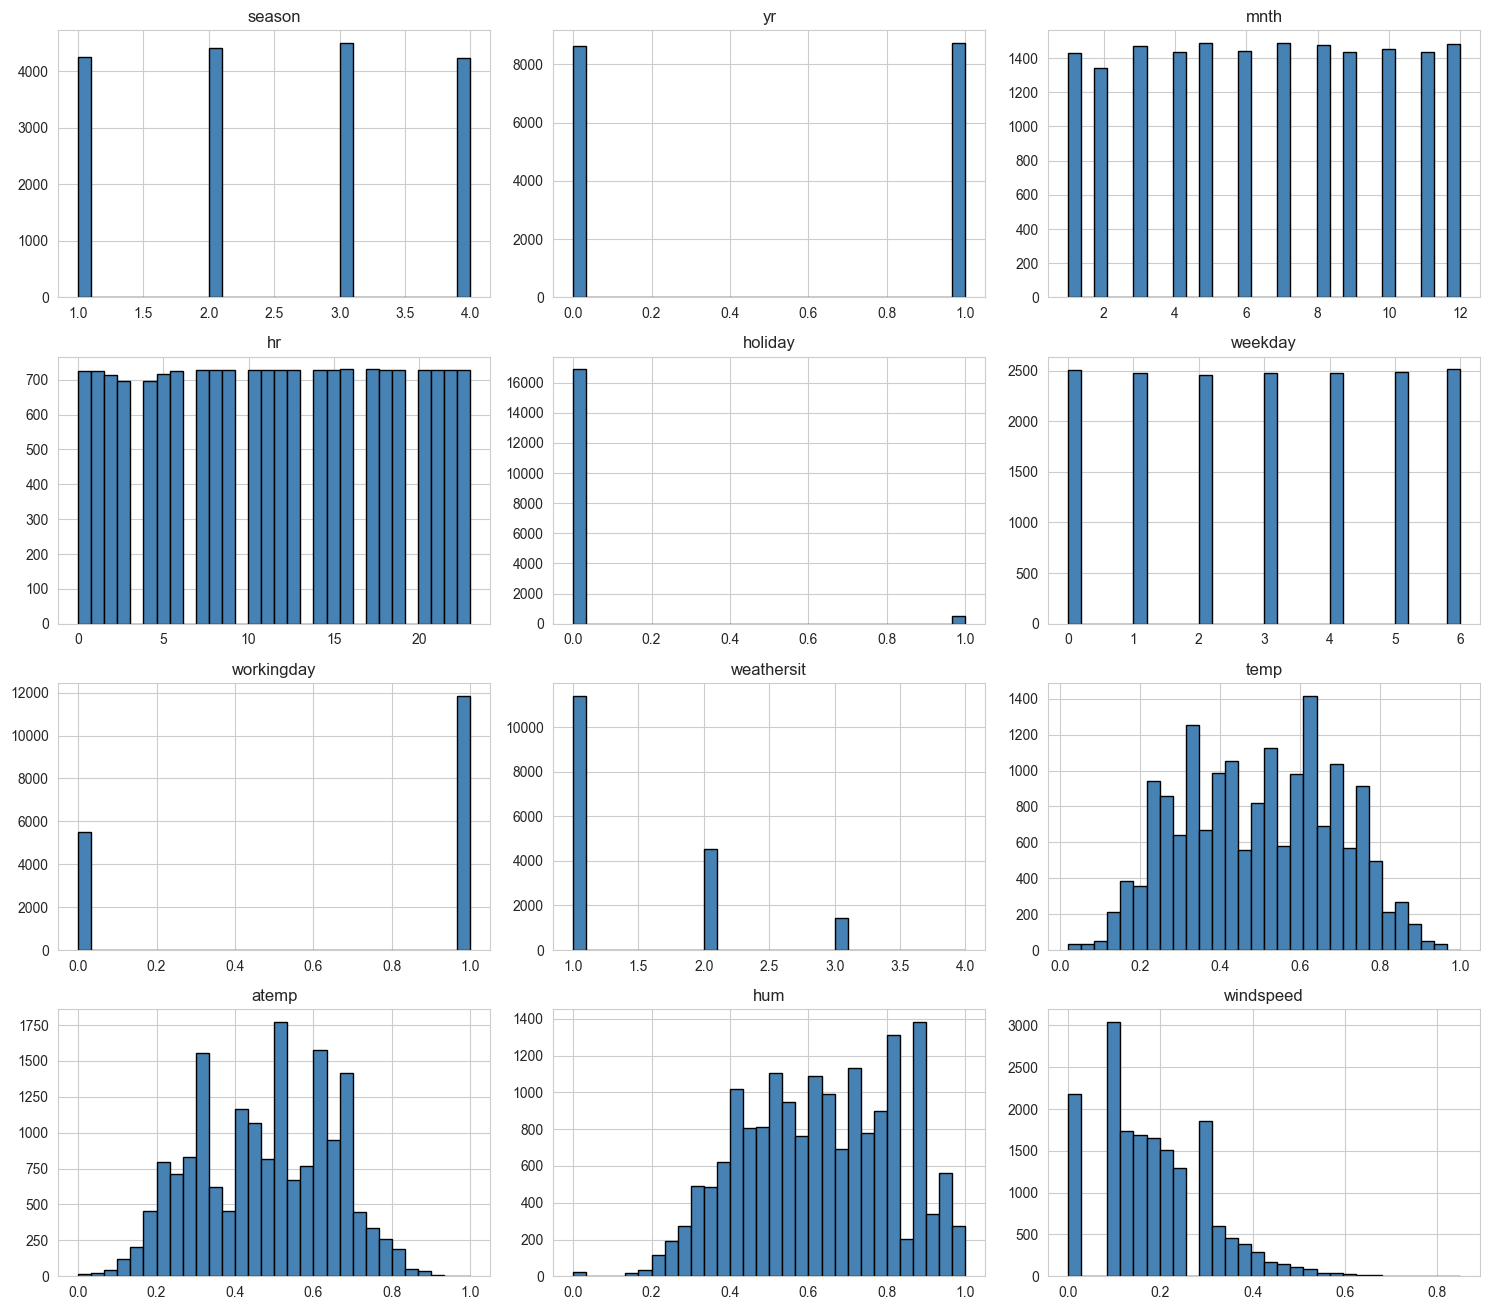

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [10]:
corrs_all = df[numeric_cols + ['cnt']].corr()['cnt'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'cnt'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
temp      0.405
atemp     0.401
hr        0.394
hum       0.323
yr        0.250
season    0.178
Name: cnt, dtype: float64


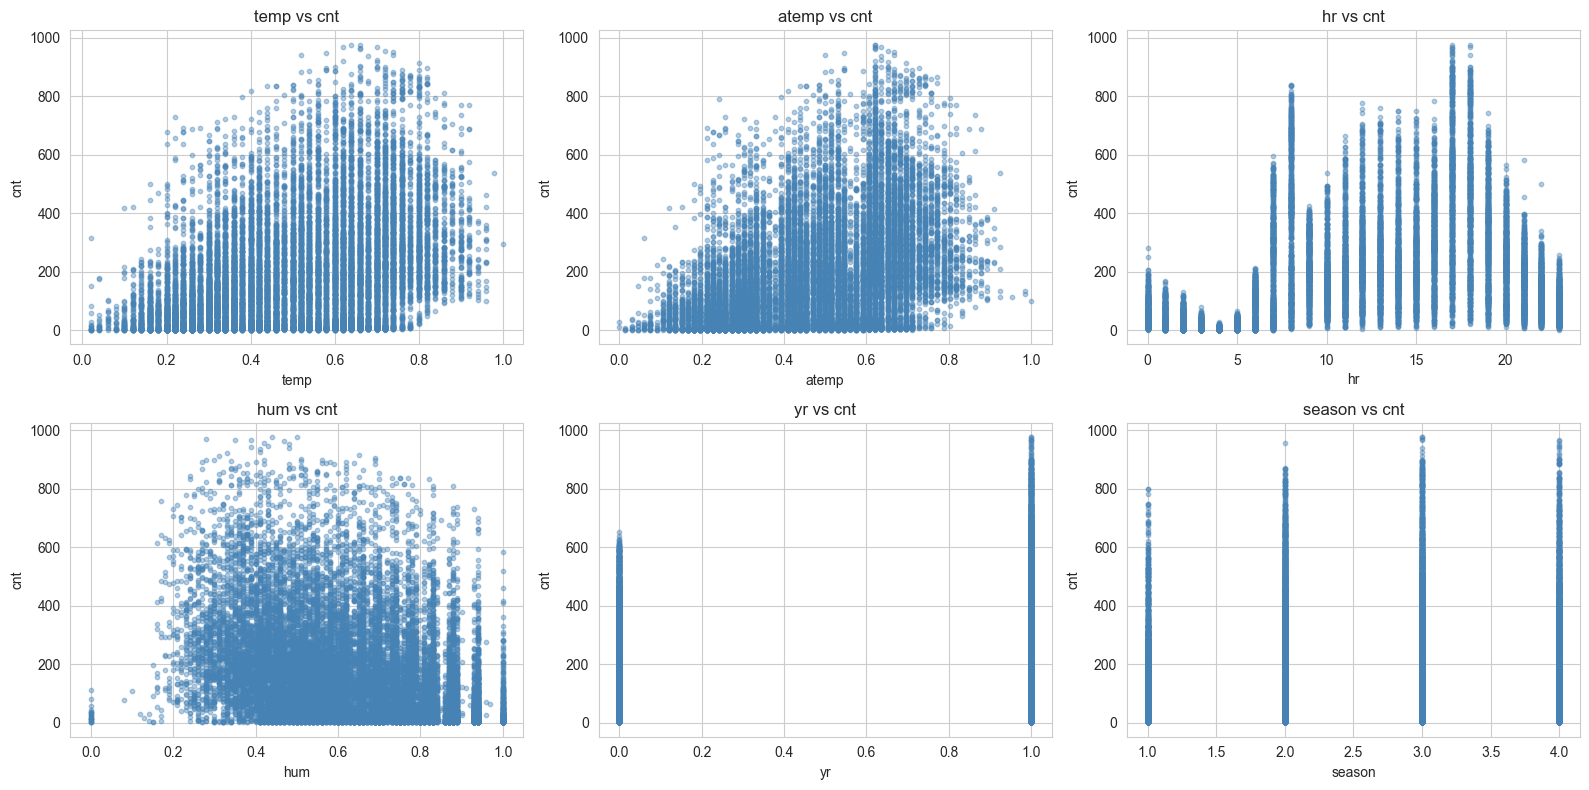

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_features[:6]):
    axes[i].scatter(df[col], df['cnt'], alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(col); axes[i].set_ylabel('cnt')
    axes[i].set_title(f'{col} vs cnt')
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

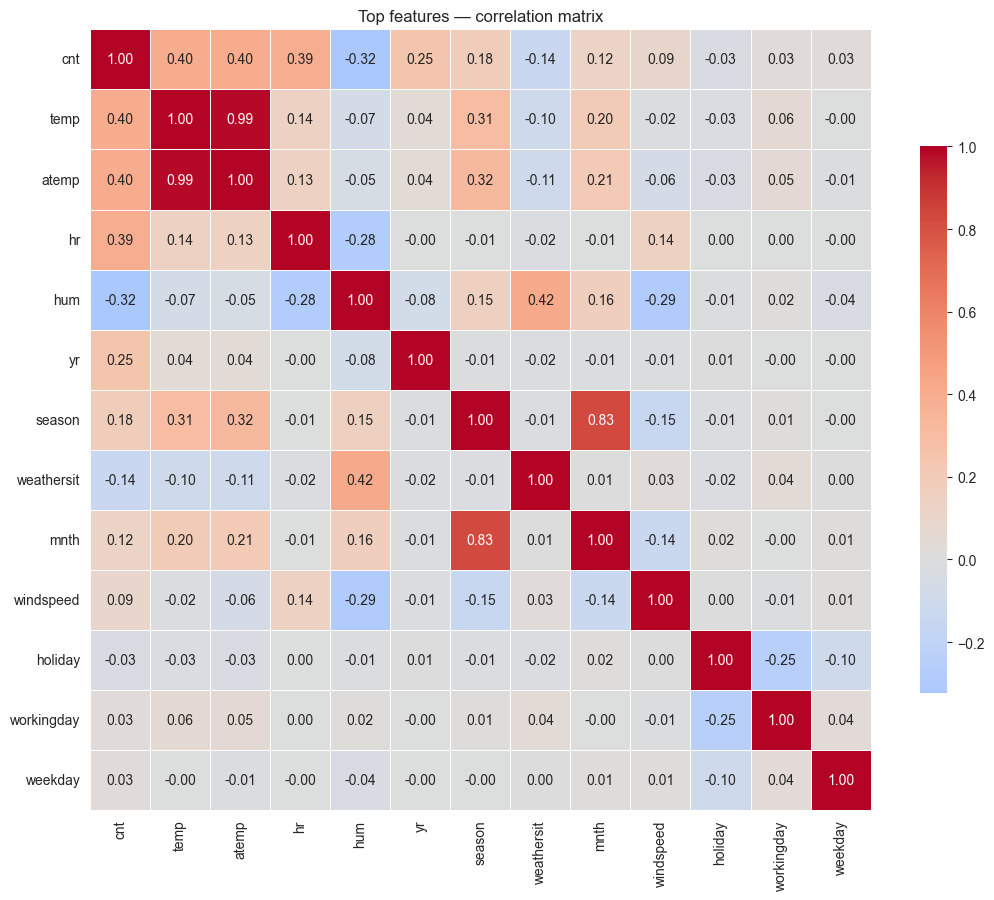

In [12]:
top_numeric = corrs_all.head(15).index.tolist()
if 'cnt' not in top_numeric:
    top_numeric.append('cnt')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

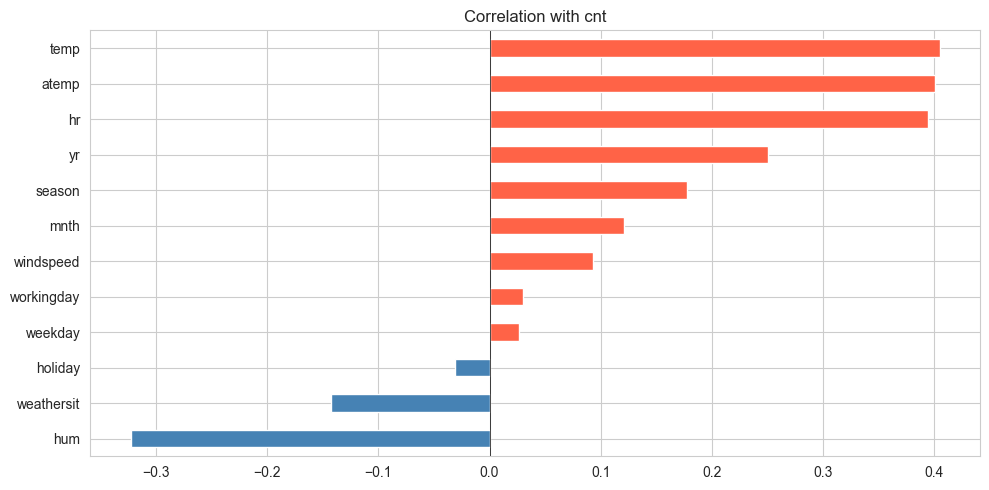

In [13]:
target_corr = df[numeric_cols + ['cnt']].corr()['cnt'].drop('cnt').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with cnt')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Hour, Weekday, Weather Effects

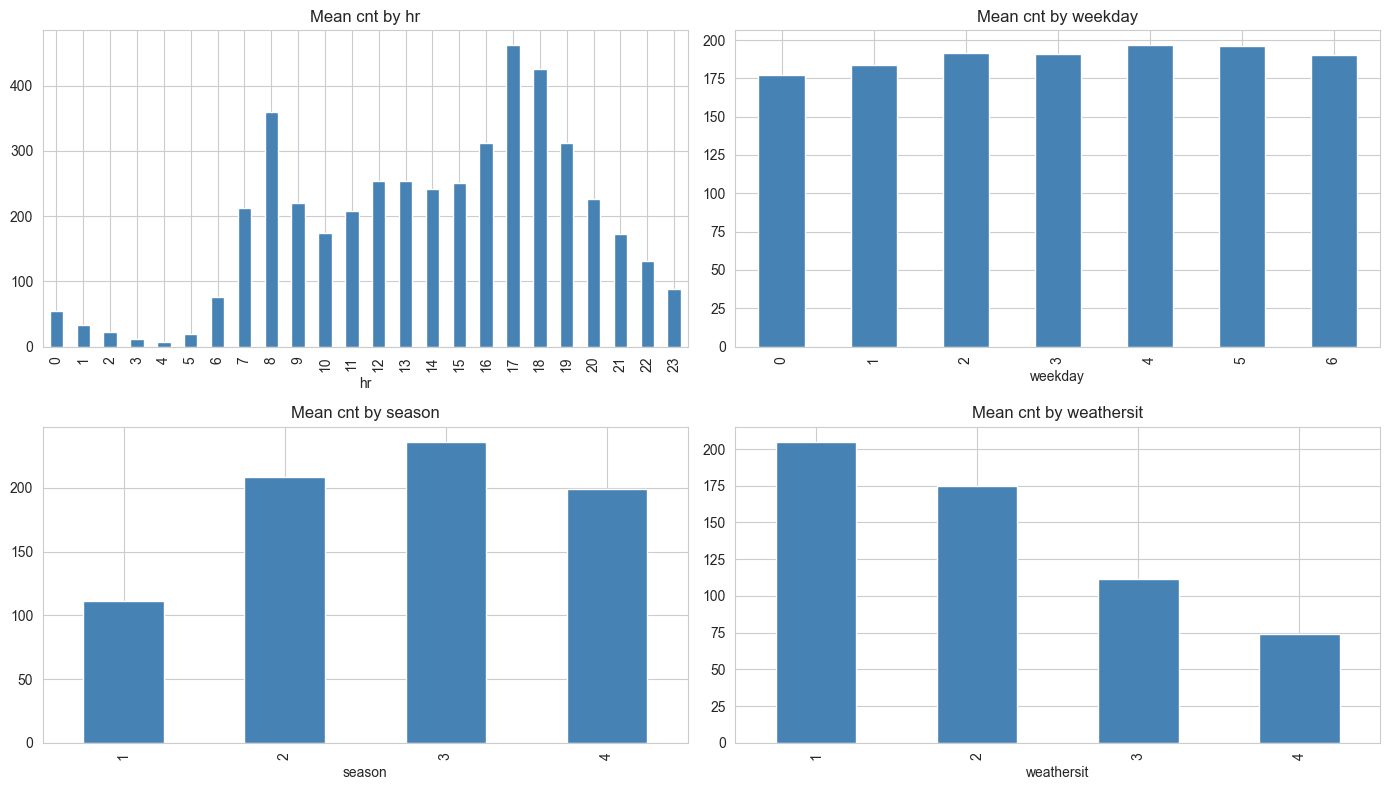

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['hr', 'weekday', 'season', 'weathersit']):
    if col in df.columns:
        df.groupby(col)['cnt'].mean().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Mean cnt by {col}')
plt.tight_layout(); plt.show()

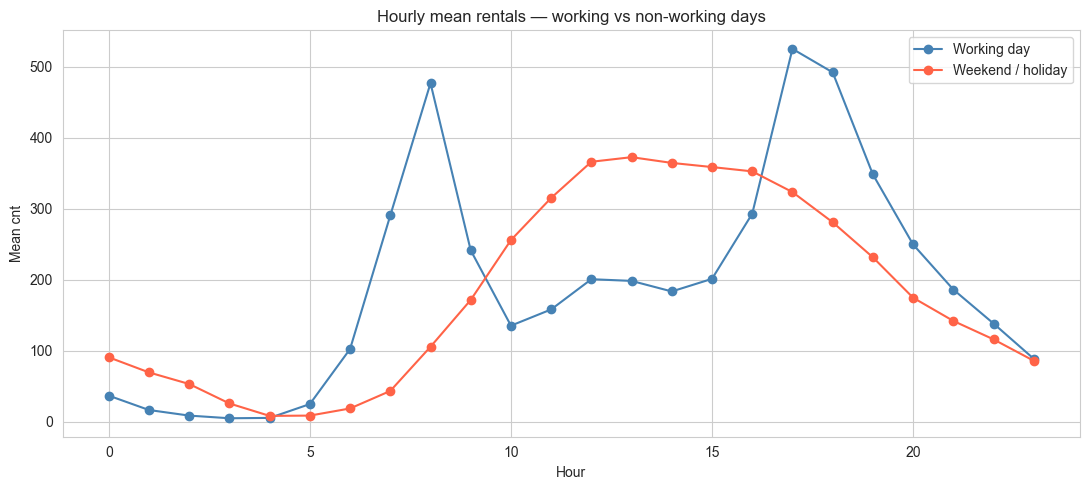

In [15]:
# Hourly demand split by working / non-working days
fig, ax = plt.subplots(figsize=(11, 5))
for wd, lbl, c in [(1, 'Working day', 'steelblue'), (0, 'Weekend / holiday', 'tomato')]:
    if 'workingday' in df.columns:
        df[df['workingday'] == wd].groupby('hr')['cnt'].mean().plot(ax=ax, marker='o', label=lbl, color=c)
ax.set_title('Hourly mean rentals — working vs non-working days')
ax.set_xlabel('Hour'); ax.set_ylabel('Mean cnt'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Pair Plot — Top Features

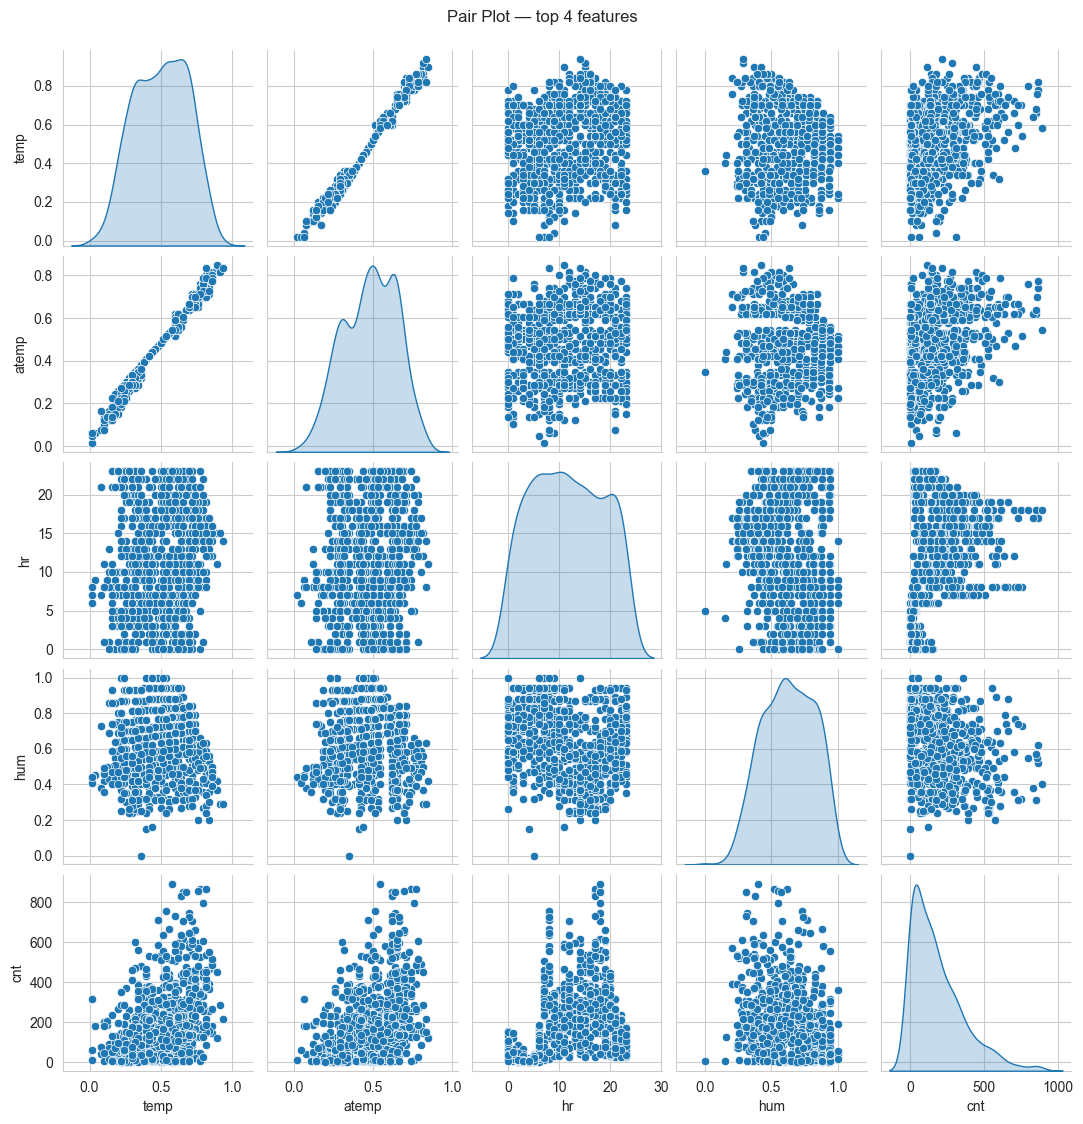

In [16]:
sample = df.sample(min(800, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['cnt']].dropna(), diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [17]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['cnt'].mean(), 2),
        round(df['cnt'].median(), 2),
        round(df['cnt'].std(), 2),
        round(df['cnt'].min(), 2),
        round(df['cnt'].max(), 2),
        round(df['cnt'].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,17379
1,Total features,12
2,Target mean,189.46
3,Target median,142.0
4,Target stddev,181.39
5,Target min,1
6,Target max,977
7,Target skewness,1.277
8,Top correlated feature,temp
9,Top correlation value,0.405
